# 3주차 과제

### 영상 시청 인증

#### 답안
yard가 클수록, bathroom이 많을수록 가격이 높다..?  
livingroom, room의 개수는 가격에 크게 상관이 없다..?  
3: 42000  
4: 13500  

In [1]:
import pandas as pd
from pandas import DataFrame, Series

import numpy as np
import os

# sklearn
import sklearn

import warnings
warnings.filterwarnings(action='ignore') 

# 노트북 실행 결과를 동일하게 유지하기 위해
np.random.seed(42)

----

## 회귀

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

### 자전거 수요 예측 데이터
#### (해당 데이터를 활용하여 자유롭게 feature를 생성해보는 것도 추천드립니다!)
    * datetime: hourly date + timestamp
    * season: 1=봄, 2=여름, 3=가을, 4=겨울
    * holiday: 1=주말을 제외한 국경일 등의 휴일, 0=휴일이 아닌 날
    * workingday: 1=주말 및 휴일이 아닌 주중, 0=주말 및 휴일
    * weather:
    * 1=맑음, 약간 구름 낀 흐림
    * 2=안개, 안개 + 흐림
    * 3=가벼운 눈, 가벼운 비 + 천둥
    * 4=심한 눈/비, 천둥/번개
    * temp: 온도(섭씨)
    * atemp: 체감온도(섭씨)
    * humidity: 상대습도
    * windspeed: 풍속
    * casual: 사전에 등록되지 않은 사용자가 대여한 횟수
    * registered: 사전에 등록된 사용자가 대여한 횟수
    * count: 대여 횟수 (target)

In [3]:
import pandas as pd

data = pd.read_csv("./data/bike.csv")

In [4]:
data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


----

#### 01. 다항회귀분석 모델을 불러오고, 데이터에 적용해보세요. (10점)

* PolynomialFeatures를 활용하여 degree=3으로 변환  
* train test 분할은 train_test_split(X_features, y_target, test_size=0.2, random_state=1004)  
* 평가지표는 RMSE 사용  

In [5]:
# X, y 분리 (1점)
# feature는 자유롭게 생성 혹은 삭제 하셔도 좋습니다!
X = data.iloc[:,4:-2]
y = data['count']

# 차원 변환 (4점)
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

# train, test 분할 (1점)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=1004)

# 모델 적용 (3점)
model = LinearRegression()
model.fit(X_train, y_train)

# 평가 (1점)
y_pred = model.predict(X_test)

# RMSE 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')


RMSE: 120.34


----

#### 02. 규제가 있는 회귀 모델을 불러오고, 데이터에 적용해보세요. 그 후, alpha 파라미터 값 변화에 따른 평가 결과를 비교해보세요. (15점)

* train test 분할은 train_test_split(X_features, y_target, test_size=0.2, random_state=1004)  
* 평가지표는 RMSE 사용  
* 규제가 있는 모델의 alpha 파라미터 값 변화에 따른 평가 결과 비교

Ridge RMSE Results:
Alpha: 0.1, RMSE: 120.34
Alpha: 1, RMSE: 120.34
Alpha: 10, RMSE: 120.31
Alpha: 100, RMSE: 120.30

Lasso RMSE Results:
Alpha: 0.1, RMSE: 120.07
Alpha: 1, RMSE: 120.08
Alpha: 10, RMSE: 120.31
Alpha: 100, RMSE: 120.77

Elastic Net RMSE Results:
Alpha: 0.1, RMSE: 120.08
Alpha: 1, RMSE: 120.14
Alpha: 10, RMSE: 120.46
Alpha: 100, RMSE: 120.75


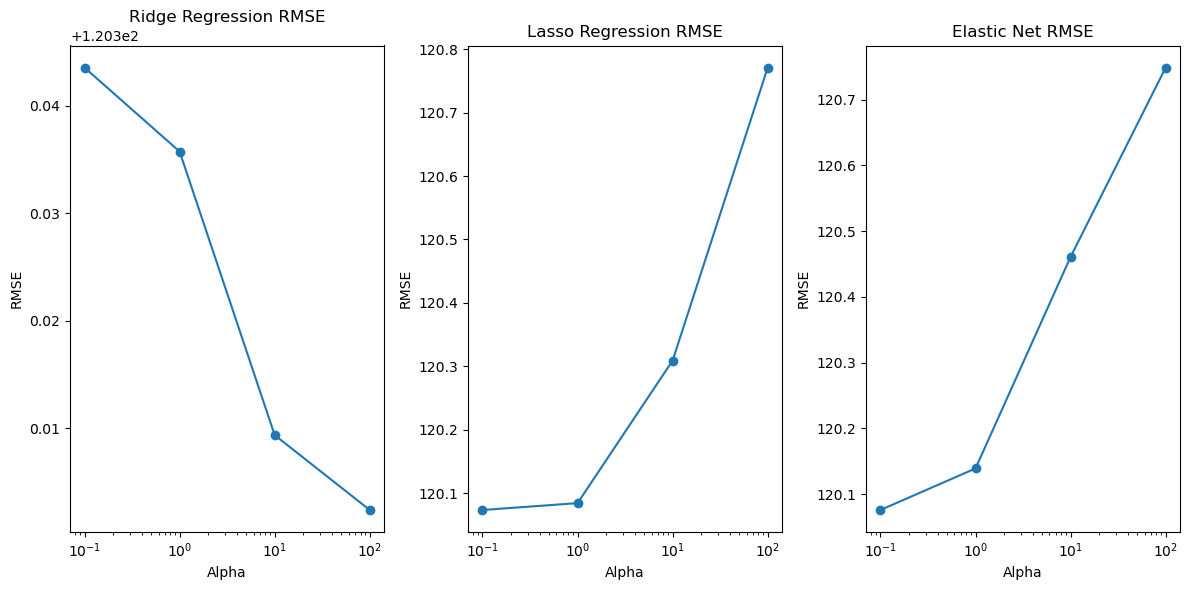

In [6]:
# train, test 분할 (1점)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=1004)

# 모델 적용 1 (Ridge) (3점)
rrmse = []
alpha = [0.1, 1, 10, 100] 

for a in alpha:
    ridge_reg = Ridge(alpha=a, random_state=42)
    ridge_reg.fit(X_train, y_train)
    y_pred = ridge_reg.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rrmse.append((a, rmse))

# 모델 적용 2 (Lasso) (3점)
lrmse = []

for a in alpha:
    lasso_reg = Lasso(alpha=a, random_state=42)
    lasso_reg.fit(X_train, y_train)
    y_pred = lasso_reg.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    lrmse.append((a, rmse))
# 모델 적용 3 (Elastic Net) (3점)
ermse = []

for a in alpha:
    elastic_net_reg = ElasticNet(alpha=a, l1_ratio=0.5, random_state=42)  # l1_ratio는 Lasso와 Ridge의 비율
    elastic_net_reg.fit(X_train, y_train)
    y_pred = elastic_net_reg.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ermse.append((a, rmse))

# 평가 (각 모델마다 RMSE 평가) (1점)
print("Ridge RMSE Results:")
for alpha, rmse in rrmse:
    print(f'Alpha: {alpha}, RMSE: {rmse:.2f}')

print("\nLasso RMSE Results:")
for alpha, rmse in lrmse:
    print(f'Alpha: {alpha}, RMSE: {rmse:.2f}')

print("\nElastic Net RMSE Results:")
for alpha, rmse in ermse:
    print(f'Alpha: {alpha}, RMSE: {rmse:.2f}')

# 평가 비교 (4점)
# 각 모델마다 alpha 값을 변화시켜 가면서 어떤 변화가 보이는지를 시각화 혹은 값 비교 등 다양한 방법을 활용하여 이를 서술해주세요.
plt.figure(figsize=(12, 6))

# Ridge RMSE
plt.subplot(1, 3, 1)
plt.plot([alpha for alpha, rmse in rrmse], [rmse for alpha, rmse in rrmse], marker='o')
plt.title("Ridge Regression RMSE")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.xscale('log') #Matplotlib에서 x축의 스케일을 로그 스케일로 설정하는 함수

# Lasso RMSE
plt.subplot(1, 3, 2)
plt.plot([alpha for alpha, rmse in lrmse], [rmse for alpha, rmse in lrmse], marker='o')
plt.title("Lasso Regression RMSE")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.xscale('log')

# Elastic Net RMSE
plt.subplot(1, 3, 3)
plt.plot([alpha for alpha, rmse in ermse], [rmse for alpha, rmse in ermse], marker='o')
plt.title("Elastic Net RMSE")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.xscale('log')

plt.tight_layout()
plt.show()


----

## 분류

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

----

### 03. SVM (총 25점)

#### 03-1) SVM모델을 불러오고, 데이터에 적용해보세요. (총 12점)

* train_test_split(X_features, y_target, test_size=0.3, random_state=42)를 통해 분할  
* 모델은 Pipeline을 사용해서 StandardScaler도 같이 사용한 경우와 안 사용했을 경우 모두 적용해보기  
* Confusion Matrix를 활용하여 평가 및 결과 해석    

<Axes: >

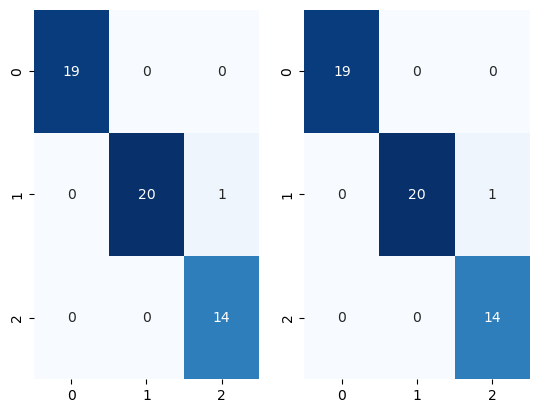

In [9]:
# data import
from sklearn.datasets import load_wine

# data 불러오기
wine=load_wine()
X_features, y_target = wine.data, wine.target

# X, y / train, test분할 (1점)/
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=42)

# 모델 적용 (8점)
# Pipeline을 활용해서 Scaler를 사용했을 때와 아닐 때를 비교해주세요.
s_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])
s_clf.fit(X_train,y_train)

ns_clf = Pipeline([
    ("svm", SVC(kernel="linear"))
])
ns_clf.fit(X_train,y_train)
# predict (3점)
spred_y = s_clf.predict(X_test)
nspred_y = ns_clf.predict(X_test)
# Confusion Matrix를 통해 어떤 결과가 나오는지 시각화 해주세요.
from sklearn.metrics import confusion_matrix
scaled_cm = confusion_matrix(y_test, spred_y)
no_scaled_cm = confusion_matrix(y_test, nspred_y)

import matplotlib.pyplot as plt
import seaborn as sns
plt.subplot(1, 2, 1)
sns.heatmap(scaled_cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.subplot(1, 2, 2)
sns.heatmap(no_scaled_cm, annot=True, fmt='d', cmap='Blues', cbar=False)


#### 01-2) 파라미터를 조정해보고, 조정했을 때 어떻게 달라지는지 알아보세요. (3가지 이상) (13점)

In [14]:
# 파라미터 1
ps_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly")) #기본차수 3차 다항식
])
ps_clf.fit(X_train,y_train)
pspred_y = ps_clf.predict(X_test)
cm1 = confusion_matrix(y_test, pspred_y)

# 파라미터 2
p3s_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=5))
])
p3s_clf.fit(X_train,y_train)
p3spred_y = p3s_clf.predict(X_test)
cm2 = confusion_matrix(y_test, p3spred_y)

# 파라미터 3
pcs_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=5, C=10)) # C=정규화 매개변수, 모델의 오차를 허용하는 정도를 설정, 값이 높을수록 민감하게
])
pcs_clf.fit(X_train,y_train)
pcspred_y = pcs_clf.predict(X_test)
cm3 = confusion_matrix(y_test, pcspred_y)

print(cm1)
print("")
print(cm2)
print("")
print(cm3)

[[17  2  0]
 [ 0 21  0]
 [ 0  0 14]]

[[12  7  0]
 [ 0 21  0]
 [ 0  3 11]]

[[18  1  0]
 [ 0 21  0]
 [ 0  2 12]]


---

## 02. KNN (총 25점)

#### 02-1) KNN모델을 불러오고, 데이터에 적용해보세요. (총 12점)

* train_test_split(X_features, y_target, test_size=0.3, random_state=42)를 통해 분할  
* 모델은 Pipeline을 사용해서 StandardScaler도 같이 사용한 경우와 안 사용했을 경우 모두 적용해보기  
* Confusion Matrix를 활용하여 평가 및 결과 해석    

<Axes: >

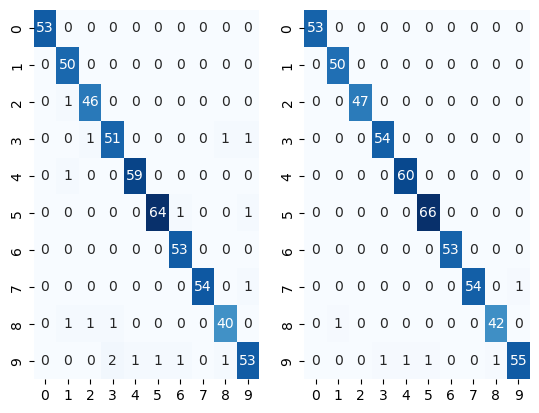

In [49]:
# data import
from sklearn.datasets import load_digits

# data 불러오기
digits=load_digits()
X_features, y_target = digits.data, digits.target

# X, y / train, test 분할 (1점)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=42)

# 모델 적용 (8점)
# Pipeline을 활용해서 Scaler를 사용했을 때와 아닐 때를 비교해주세요.
s_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", KNeighborsClassifier(n_neighbors=3, weights='uniform', p=2))
])
s_knn.fit(X_train,y_train)

ns_knn = Pipeline([
    ("KNN", KNeighborsClassifier(n_neighbors=3, weights='uniform', p=2))
])
ns_knn.fit(X_train,y_train)

# predict (3점)
spred_y = s_knn.predict(X_test)
nspred_y = ns_knn.predict(X_test)
# Confusion Matrix를 통해 어떤 결과가 나오는지 시각화 해주세요.
from sklearn.metrics import confusion_matrix
scaled_cm = confusion_matrix(y_test, spred_y)
no_scaled_cm = confusion_matrix(y_test, nspred_y)

import matplotlib.pyplot as plt
import seaborn as sns
plt.subplot(1, 2, 1)
sns.heatmap(scaled_cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.subplot(1, 2, 2)
sns.heatmap(no_scaled_cm, annot=True, fmt='d', cmap='Blues', cbar=False)



#### 02-2) 파라미터를 조정해보고, 조정했을 때 어떻게 달라지는지 알아보세요. (3가지 이상) (13점)

In [53]:
# 파라미터 1 (이웃수 5, 가까운 이웃에게 가중치 더 줌, 거리계산기준 1)
s1_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", KNeighborsClassifier(n_neighbors=5, weights='distance', p=1))
])
s1_knn.fit(X_train,y_train)
s1pred_y = s1_knn.predict(X_test)
cm1 = confusion_matrix(y_test, s1pred_y)

# 파라미터 2
s2_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", KNeighborsClassifier(n_neighbors=7, weights='uniform', p=3)) #모든이웃에게 동일한 가중치
])
s2_knn.fit(X_train,y_train)
s2pred_y = s2_knn.predict(X_test)
cm2 = confusion_matrix(y_test, s2pred_y)


# 파라미터 3
s3_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", KNeighborsClassifier(n_neighbors=3, weights='distance', p=3))
])
s3_knn.fit(X_train,y_train)
s3pred_y = s3_knn.predict(X_test)
cm3 = confusion_matrix(y_test, s3pred_y)

print(cm1)
print("")
print(cm2)
print("")
print(cm3)

[[53  0  0  0  0  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  0 53  0  0  0  0  1  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  1 62  1  0  0  2]
 [ 1  0  0  0  0  0 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  2  0  0  0  0  0  0 40  1]
 [ 0  0  0  2  1  1  0  0  0 55]]

[[53  0  0  0  0  0  0  0  0  0]
 [ 0 49  1  0  0  0  0  0  0  0]
 [ 0  2 45  0  0  0  0  0  0  0]
 [ 0  0  1 52  0  0  0  0  1  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  0 64  1  0  0  1]
 [ 0  0  0  0  0  0 53  0  0  0]
 [ 0  0  0  0  0  1  0 53  1  0]
 [ 0  0  0  0  0  0  0  0 43  0]
 [ 0  0  0  1  0  1  1  1  1 54]]

[[52  0  0  0  0  1  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  1 46  0  0  0  0  0  0  0]
 [ 0  0  2 51  0  0  0  0  0  1]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  0  0  0  0 64  1  0  0  1]
 [ 0  0  0  0  0  0 53  0  0  0]
 [ 0  0  0  0  0  1  0 53  0  1]
 [ 0  1  1  1  0  0  0  0 40  0]
 [ 0  0  0  2  0  0  1  0  2 54]]


---

## 03. Decision Tree (총 25점)

#### 03-1) DT모델을 불러오고, 데이터에 적용해보세요. (총 12점)

* train_test_split(X_features, y_target, test_size=0.3, random_state=42)를 통해 분할  
* random_state를 0으로 한 경우와 다양하게 파라미터를 변경해보고, tree를 시각화했을 때 변하는 것이 있는지 확인해보기  

* ROC_AUC와 Accuarcy 점수를 구하기  
* plot_tree(모델이름, feature_names = explt_vars, class_names = fct_val, filled = True) 을 사용해서 시각화  

In [16]:
# 사용한 데이터 : breast_cancer dataset
from sklearn.datasets import load_breast_cancer

breast_cancer=load_breast_cancer()
X_features, y_target = breast_cancer.data, breast_cancer.target

explt_vars = ['mean radius', 'mean texture', 'mean perimeter', 'mean area','mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension','radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error','concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture','worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points','worst symmetry', 'worst fractal dimension']
fct_val = ['malignant','benign']

[Text(0.625, 0.9375, 'mean concave points <= 0.051\ngini = 0.468\nsamples = 398\nvalue = [149, 249]\nclass = benign'),
 Text(0.4318181818181818, 0.8125, 'worst radius <= 16.83\ngini = 0.1\nsamples = 245\nvalue = [13, 232]\nclass = benign'),
 Text(0.3181818181818182, 0.6875, 'radius error <= 0.626\ngini = 0.043\nsamples = 230\nvalue = [5, 225]\nclass = benign'),
 Text(0.22727272727272727, 0.5625, 'worst smoothness <= 0.178\ngini = 0.026\nsamples = 227\nvalue = [3, 224]\nclass = benign'),
 Text(0.18181818181818182, 0.4375, 'smoothness error <= 0.003\ngini = 0.018\nsamples = 226\nvalue = [2, 224]\nclass = benign'),
 Text(0.09090909090909091, 0.3125, 'worst perimeter <= 99.845\ngini = 0.32\nsamples = 5\nvalue = [1, 4]\nclass = benign'),
 Text(0.045454545454545456, 0.1875, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = benign'),
 Text(0.13636363636363635, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = malignant'),
 Text(0.2727272727272727, 0.3125, 'worst texture <= 33.35\ngini

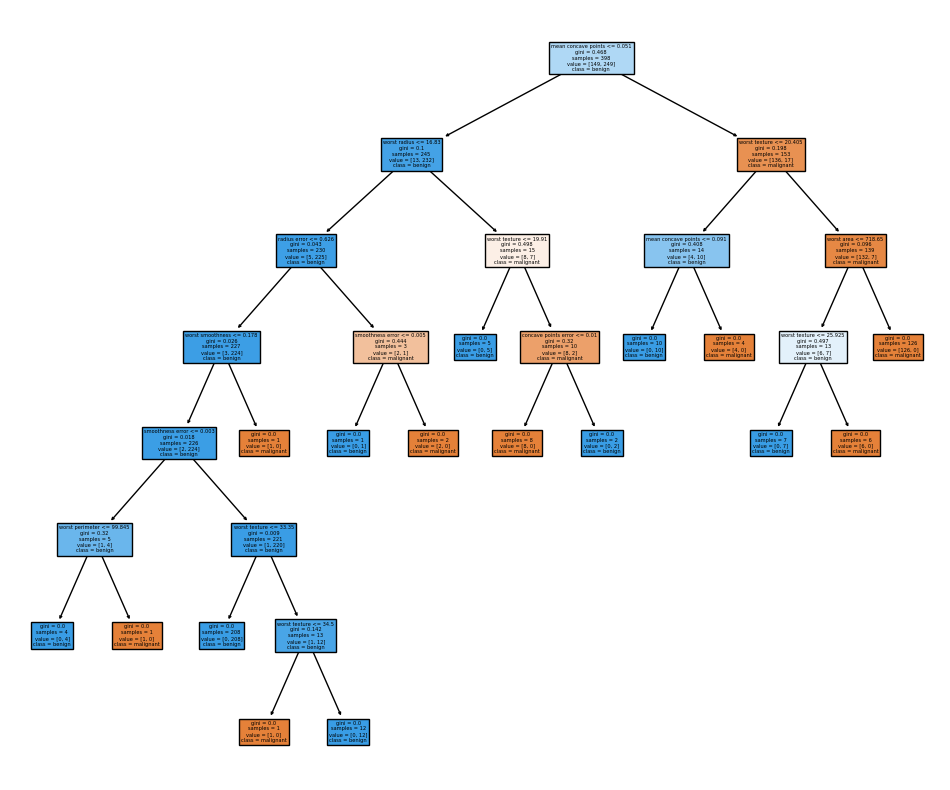

In [18]:
# X, y / train, test 분할 (1점)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=42)


# 모델 적용 fit (4점)
tree_clf = DecisionTreeClassifier(random_state=0)
tree_clf.fit(X_train, y_train)

# predict (2점)
y0_pred = tree_clf.predict(X_test)
roc_auc = roc_auc_score(y_test, tree_clf.predict_proba(X_test)[:, 1])
accuracy = accuracy_score(y_test, y0_pred)

# 두번째 모델
tree2_clf = DecisionTreeClassifier(random_state=0,  max_depth=3, min_samples_split=10)
tree2_clf.fit(X_train, y_train)

# predict (2점)
y1_pred = tree2_clf.predict(X_test)
roc_auc = roc_auc_score(y_test, tree2_clf.predict_proba(X_test)[:, 1])
accuracy = accuracy_score(y_test, y1_pred)


# tree 시각화 (5점)
# random state 값 혹은 파라미터를 변화시켜 가면서 plot_tree의 변화를 확인해보고, 이를 간략히 서술해주세요.
plt.figure(figsize = (12,10)) # 크기 조절
plot_tree(tree_clf, feature_names = explt_vars, class_names = fct_val, filled = True)

# 파라미터로 트리의 최대 깊이를 3으로 하고 분할되기 위해 노드가 가져야 하는 최고 샘플수를 10으로 맞춰보니 
# plot_tree가 확실히 간단하게 보였고 한눈에 확인하며 이해하기 쉬웠다.

[Text(0.5, 0.875, 'mean concave points <= 0.051\ngini = 0.468\nsamples = 398\nvalue = [149, 249]\nclass = benign'),
 Text(0.25, 0.625, 'worst radius <= 16.83\ngini = 0.1\nsamples = 245\nvalue = [13, 232]\nclass = benign'),
 Text(0.125, 0.375, 'radius error <= 0.626\ngini = 0.043\nsamples = 230\nvalue = [5, 225]\nclass = benign'),
 Text(0.0625, 0.125, 'gini = 0.026\nsamples = 227\nvalue = [3, 224]\nclass = benign'),
 Text(0.1875, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [2, 1]\nclass = malignant'),
 Text(0.375, 0.375, 'mean texture <= 16.19\ngini = 0.498\nsamples = 15\nvalue = [8, 7]\nclass = malignant'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]\nclass = benign'),
 Text(0.4375, 0.125, 'gini = 0.32\nsamples = 10\nvalue = [8, 2]\nclass = malignant'),
 Text(0.75, 0.625, 'worst texture <= 20.405\ngini = 0.198\nsamples = 153\nvalue = [136, 17]\nclass = malignant'),
 Text(0.625, 0.375, 'worst perimeter <= 119.65\ngini = 0.408\nsamples = 14\nvalue = [4, 10]\nclass = beni

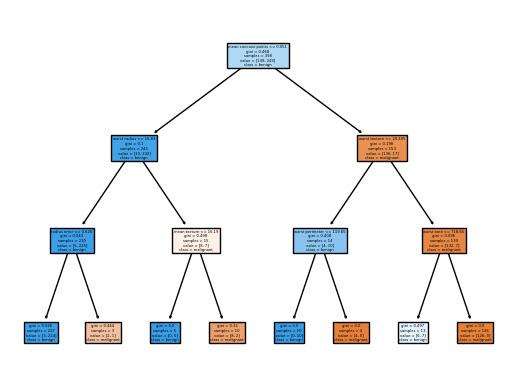

In [19]:
plot_tree(tree2_clf, feature_names = explt_vars, class_names = fct_val, filled = True)

#### 03-2) 파라미터를 조정해보고, 조정했을 때 어떻게 달라지는지 알아보세요. (3가지 이상) (13점)
* 각 파라미터가 어떤 역할을 하는지 간단하게 설명도 해주세요

In [15]:
# 파라미터 1
# 리프노드에 있어야할 최소 샘플 수를 조정한다. 이 값을 늘리면 과적합 방지에 도움이 된다
tree_clf_3 = DecisionTreeClassifier(random_state=0, min_samples_leaf=5)

# 파라미터 2
# 각 분할에서 고려할 최대 피처수를 정한다. 이값을 조정해서 모델의 다양성을 높일 수 있다.
tree_clf_4 = DecisionTreeClassifier(random_state=0, max_features='sqrt') # 분할시 사용할 특성수를 전체 특성수의 제곱근 만큼 반영

# 파라미터 3
# 분할 품질을 측정하는 데 도움이 되는 함수다.
tree_clf_5 = DecisionTreeClassifier(random_state=0, criterion='entropy') # 엔트로피(불순도)가 낮을수록 더 좋은 분할로 간주
